In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
train_digits = []
with open('/content/drive/MyDrive/Courses/2023 Fall CMPE 257/Colab/digits/ZipDigits.train') as fp:
    for line in fp:
        train_digits.append([float(x) for x in line.split()])

train_digits = np.array(train_digits)


In [4]:
train_digits.shape

(7291, 257)

In [5]:
def print_digit(digit_row):
    digit_row = digit_row[1:257]
    digit_row = digit_row.reshape(16, 16)
    digit_row = (digit_row + 1)/2
    plt.imshow(digit_row, cmap='gray', vmin=0, vmax=1)


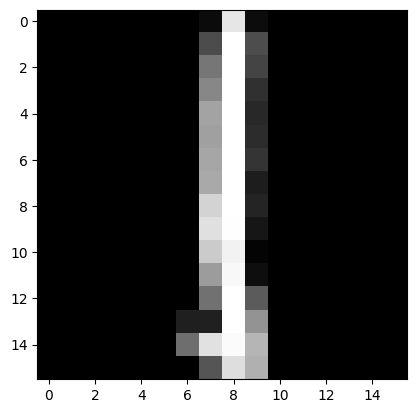

In [6]:
print_digit(train_digits[9])

My Helper Functions

In [7]:
def extract_features(digit_row):
    intensity = np.sum((digit_row + 1)/2)/256
    digit_row = digit_row[1:257]
    digit_row = digit_row.reshape(16, 16)
    flipped_hor = np.flip(digit_row, 1)
    flipped_ver = np.flip(digit_row, 0)
    hor_symmetry = np.sum(np.multiply(digit_row, flipped_hor))/256
    ver_symmetry = np.sum(np.multiply(digit_row, flipped_ver))/256
    symmetry = (hor_symmetry+ ver_symmetry)/2
    return intensity, symmetry

In [8]:
def plot_features(X, y):
    colors = []
    for y_col in y:
        if y_col == 1:
            colors.append('b')
        else:
            colors.append('r')
    plt.scatter(X[:,0], X[:,1], color=colors)

def abline(slope, intercept):
    """Plot a line from slope and intercept"""
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--', label = "x_2="+str(slope)+"x_1+"+str(intercept) )

In [9]:
digit1 = 2
digit2 = 8
train = train_digits[(train_digits[:,0] == digit1) | (train_digits[:,0] == digit2)]

In [10]:
X = []
y = []
for row in train:
    intensity, symmetry = extract_features(row)
    X.append([intensity, symmetry])
    if row[0] == digit1:
        y.append(1)
    else:
        y.append(-1)

X = np.array(X)
y = np.array(y)


In [11]:
import pandas as pd
df = pd.DataFrame()
df['x1'] = X[:,0]
df['x2'] = X[:,1]
df['y'] = y
df.info()
df.to_csv('2vs8.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      1273 non-null   float64
 1   x2      1273 non-null   float64
 2   y       1273 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 30.0 KB


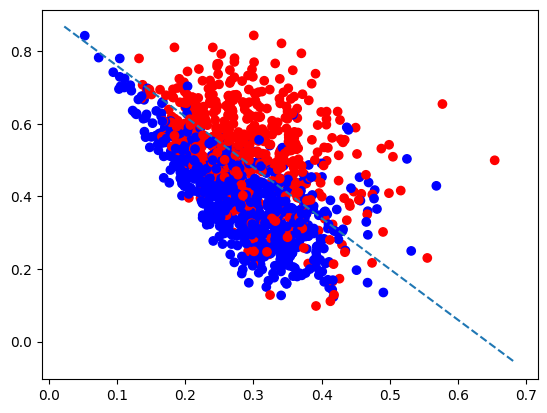

In [12]:
plot_features(X, y)
axes = plt.gca()
w = [0.9, -1.4, -1]
x_vals = np.array(axes.get_xlim())
y_vals = -w[0]/w[2] - w[1]/w[2] * x_vals
plt.plot(x_vals, y_vals, '--')

In [13]:
def sign(x):
    if x >= 0:
        return 1
    else:
        return -1


total = len(X)
correct = 0
separable = []
for (x_i, y_i) in zip(X, y):
  y_pred = sign(w[0] + w[1]*x_i[0] + w[2]*x_i[1])
  if y_pred == y_i:
    correct = correct + 1
    separable.append([x_i[0], x_i[1], y_i])

print(correct/total)
print(total)

0.7737627651217597
1273


In [14]:
sep_df = pd.DataFrame(separable)
sep_df.head()

,0,1,2
0,0.458248,0.407339,-1
1,0.308186,0.236474,1
2,0.170111,0.590144,1
3,0.239096,0.424140,1
4,0.305740,0.475571,-1


In [15]:
sep_df['x0'] = 1
cols = ['x0', 0, 1, 2]
sep_df = sep_df[cols]

In [16]:
def get_sign(x, w):
  dot_product = x[0]*w[0] + x[1]*w[1] + x[2]*w[2]
  return sign(dot_product)

# x includes y as the last column
def findMisclassified(x, y, w):
    for (x_i, y_i) in zip(x, y):
      s = get_sign(x_i, w)
      if s*y_i < 0:
          return x_i, y_i
    return [], 0

def PLA(df):
  maxiters = 100000
  w = [-1, 1, 1] #initialize w
  df_x = df.iloc[:, 0:3]
  df_y = df.iloc[:, 3]
  iters = 0
  while True:
    x_mis, y_mis = findMisclassified(df_x.values, df_y.values, w)
    if ((y_mis == 0) or (iters > maxiters)):
      break
    iters = iters + 1
    w = w + x_mis * y_mis
  print(iters)
  return w

In [17]:
w = PLA(sep_df)
print(w)

98094
[ 133.         -207.14911523 -147.70795505]


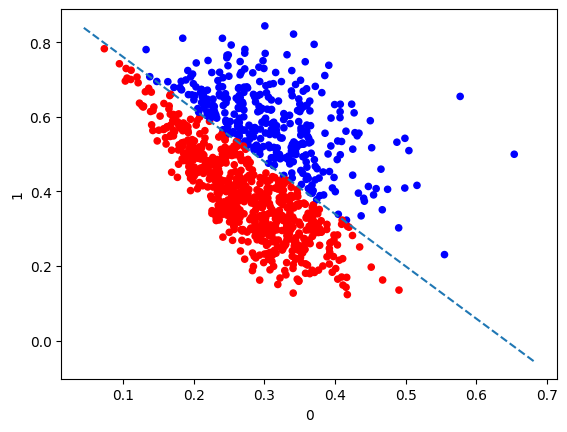

In [18]:
col = sep_df[2].map({-1:'b', 1:'r'})
sep_df.plot.scatter(x=0, y=1, c=col)
axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = -w[0]/w[2] - w[1]/w[2] * x_vals
plt.plot(x_vals, y_vals, '--')

In [19]:
sep_df.to_csv('separable2vs8.csv', index=False)